## Amazon Inc. (AMZN) — Sentiment Analysis & Correlation

### Overview
This notebook quantifies the relationship between financial news sentiment
and daily AMZN stock price returns. We apply VADER sentiment analysis to
news headlines, compute daily stock returns, and measure the statistical
correlation between the two using Pearson, Spearman and Kendall methods.

### Objectives
- Compare TextBlob vs VADER for financial headline sentiment analysis
- Align news publication dates to AMZN trading days
- Score each headline using VADER sentiment analysis
- Aggregate daily sentiment scores
- Compute daily stock returns
- Measure correlation between sentiment and returns
- Visualize and interpret the relationship



**We use VADER** because financial headlines are short, punchy, and often
use capitalization and punctuation for emphasis — exactly the context VADER
was designed for. TextBlob tends to classify too many financial headlines
as neutral, reducing sensitivity to meaningful sentiment shifts.

In [16]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('vader_lexicon', quiet=True)

from src.data_loader import load_news_data, filter_by_stock, load_stock_data
from src.sentiment_analyzer import (
    score_headlines_vader,
    score_headlines_textblob,
    classify_sentiment,
    align_dates,
    aggregate_daily_sentiment,
    compute_daily_returns,
    merge_sentiment_returns,
    compute_correlation
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'serif'

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Data

We load both the financial news dataset and AMZN stock price data
using our modular data loading functions from src/data_loader.py.

In [17]:
# Load news data
df_news = load_news_data('../data/raw/raw_analyst_ratings.csv')

# Filter for AMZN
amzn_news = filter_by_stock(df_news, 'AMZN')

# Load stock price data
amzn_stock = load_stock_data('../data/raw/AMZN.csv')

print(f"\nNews articles  : {len(amzn_news)}")
print(f"Stock records  : {len(amzn_stock)}")
print(f"\nNews date range  : {amzn_news['date'].min().date()} to {amzn_news['date'].max().date()}")
print(f"Stock date range : {amzn_stock['Date'].min().date()} to {amzn_stock['Date'].max().date()}")

✅ Loaded 1407328 news articles.
✅ Found 278 articles for AMZN.
✅ Loaded 3774 rows. No missing values.

News articles  : 278
Stock records  : 3774

News date range  : 2020-04-27 to 2020-06-10
Stock date range : 2009-01-02 to 2023-12-29


## 3. TextBlob vs VADER Comparison

Before proceeding with our main analysis, we demonstrate the difference
between TextBlob and VADER on a sample of real AMZN headlines to justify
our tool selection.

In [18]:
# Sample 10 headlines for comparison
sample_headlines = amzn_news['headline'].sample(10, random_state=42).tolist()

# Score with both tools
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

sia = SentimentIntensityAnalyzer()
comparison = []

for h in sample_headlines:
    vader_compound = sia.polarity_scores(h)['compound']
    tb_polarity = TextBlob(h).sentiment.polarity

    vader_label = classify_sentiment(vader_compound)
    tb_label = ('Positive' if tb_polarity > 0.1
                else 'Negative' if tb_polarity < -0.1
                else 'Neutral')

    comparison.append({
        'headline': h[:60] + '...' if len(h) > 60 else h,
        'vader_compound': round(vader_compound, 3),
        'vader_label': vader_label,
        'tb_polarity': round(tb_polarity, 3),
        'tb_label': tb_label,
        'agreement': '✅' if vader_label == tb_label else '❌'
    })

comp_df = pd.DataFrame(comparison)
print("=== TextBlob vs VADER Comparison ===")
print(comp_df.to_string(index=False))
print(f"\nAgreement rate: {(comp_df['agreement'] == '✅').sum()}/10")

=== TextBlob vs VADER Comparison ===
                                                       headline  vader_compound vader_label  tb_polarity tb_label agreement
Fandom, America's Navy Partner For Warzone Tournament To Cel...           0.791    Positive       -0.100  Neutral         ❌
            With This NASDAQ-100 Soaring, Don't Forget This ETF           0.170    Positive        0.000  Neutral         ❌
B of A Securities Reiterates Buy on Amazon.com, Raises Price...           0.296    Positive        0.000  Neutral         ❌
Vista Equity Invests $1.5B In India's Jio Platforms, Joining...           0.000     Neutral        0.000  Neutral         ✅
Three High-Quality Companies To Bet On In A Post-Coronavirus...           0.000     Neutral        0.000  Neutral         ✅
                            3 ETFs To Buy For Amazon's Earnings           0.000     Neutral        0.000  Neutral         ✅
        USPS on horns of dilemma as it weighs parcel rate hikes          -0.178    Negative    

## 4. Date Alignment

We normalize news publication timestamps to UTC and align them to
the nearest AMZN trading day. Articles published on weekends or
market holidays are mapped to the next available trading day.
This ensures every news article is matched to a valid stock return.

In [19]:
# Align news dates to trading days
amzn_news_aligned = align_dates(amzn_news, amzn_stock)

print(f"Total articles after alignment : {len(amzn_news_aligned)}")

# Check for unmatched articles
unmatched = amzn_news_aligned['trading_date'].isna().sum()
print(f"Unmatched articles             : {unmatched}")

print(f"\nSample of aligned dates:")
print(amzn_news_aligned[
    ['date', 'date_only', 'trading_date', 'headline']
].head(10).to_string(index=False))

Total articles after alignment : 278
Unmatched articles             : 0

Sample of aligned dates:
                     date  date_only trading_date                                                                                                                                  headline
2020-06-10 17:18:50+00:00 2020-06-10   2020-06-10                                                How Cannabis Company Cannaphyll Is Marketing On Mass-Consumer Platforms, Google And Amazon
2020-06-10 15:33:26+00:00 2020-06-10   2020-06-10                                                                     Tech Stocks And FAANGS Strong Again To Start Day As Market Awaits Fed
2020-06-10 11:53:47+00:00 2020-06-10   2020-06-10                                                   Benzinga Pro's Top 5 Stocks To Watch For Wed., Jun. 10, 2020: AAPL, BAC, NIO, SONO, GLW
2020-06-10 11:20:03+00:00 2020-06-10   2020-06-10 Hearing Vertical Group Out Positive On Amazon, Saying Co.'s Ad Spend Revenues Are Increasing As Ship

## 5. Sentiment Scoring with VADER

We apply VADER SentimentIntensityAnalyzer to each headline to compute
a compound sentiment score ranging from -1 (most negative) to +1 (most
positive). Each article is then classified as:
- **Positive** — compound score >= 0.05
- **Neutral**  — compound score between -0.05 and 0.05
- **Negative** — compound score <= -0.05

In [20]:
# Score headlines with VADER
amzn_news_scored = score_headlines_vader(amzn_news_aligned)

# Add sentiment label
amzn_news_scored['sentiment_label'] = amzn_news_scored['compound'].apply(
    classify_sentiment)

print("=== VADER Sentiment Score Statistics ===")
print(amzn_news_scored['compound'].describe())
print(f"\nSentiment Distribution:")
print(amzn_news_scored['sentiment_label'].value_counts())

amzn_news_scored[['headline', 'compound',
                   'sentiment_label']].head(10)

=== VADER Sentiment Score Statistics ===
count    278.000000
mean       0.110024
std        0.304855
min       -0.868900
25%        0.000000
50%        0.000000
75%        0.296000
max        0.880700
Name: compound, dtype: float64

Sentiment Distribution:
sentiment_label
Positive    137
Neutral      94
Negative     47
Name: count, dtype: int64


,headline,compound,sentiment_label
0,How Cannabis Company Cannaphyll Is Marketing O...,0.1779,Positive
1,Tech Stocks And FAANGS Strong Again To Start D...,0.5574,Positive
2,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",0.2023,Positive
3,"Hearing Vertical Group Out Positive On Amazon,...",0.6486,Positive
4,Big Tech Reaches New Record Heights At The Sto...,0.0516,Positive
5,"Twitter, Square Will Mark Juneteenth As Holida...",0.7096,Positive
6,'Inside Amazon's plan to test warehouse worker...,0.0000,Neutral
7,"BofA Raises Amazon Target On Sales Upside, Acc...",0.5106,Positive
8,Amazon shares are trading higher despite marke...,0.6407,Positive
9,IRS Alerts Against Criminals Profiteering From...,-0.8402,Negative


### 5.1 Sentiment Distribution Visualization

The charts below show the distribution of compound sentiment scores
and the breakdown of positive, neutral and negative articles.

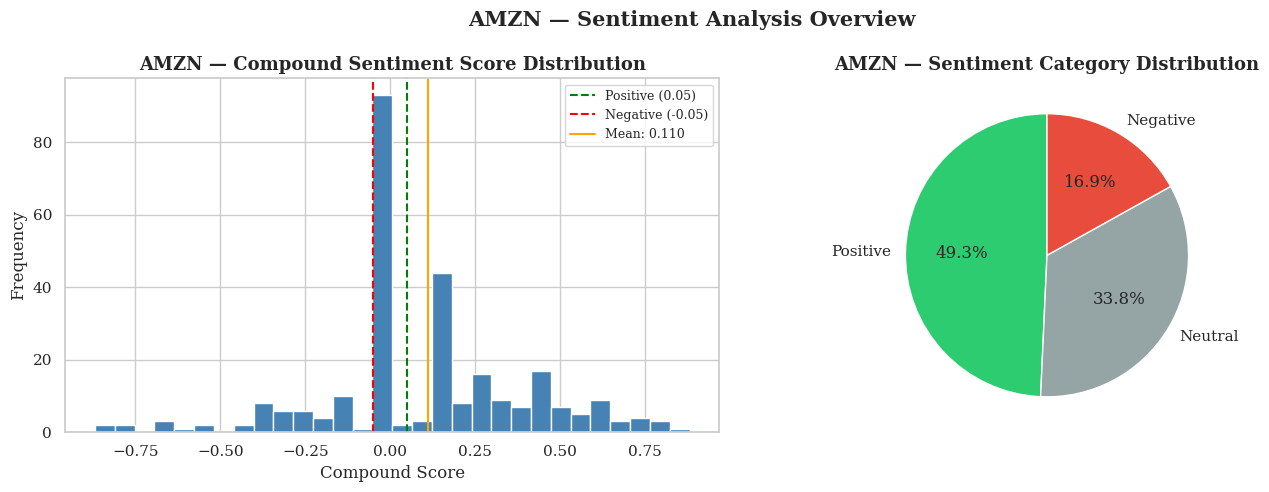

✅ Sentiment distribution plot rendered!


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(amzn_news_scored['compound'], bins=30,
             color='steelblue', edgecolor='white')
axes[0].axvline(0.05,  color='green', linestyle='--',
                label='Positive (0.05)')
axes[0].axvline(-0.05, color='red',   linestyle='--',
                label='Negative (-0.05)')
axes[0].axvline(amzn_news_scored['compound'].mean(),
                color='orange', linestyle='-',
                label=f"Mean: {amzn_news_scored['compound'].mean():.3f}")
axes[0].set_title('AMZN — Compound Sentiment Score Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Pie chart
sentiment_counts = amzn_news_scored['sentiment_label'].value_counts()
colors_pie = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}
axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=[colors_pie[s] for s in sentiment_counts.index],
    autopct='%1.1f%%', startangle=90)
axes[1].set_title('AMZN — Sentiment Category Distribution',
                  fontsize=13, fontweight='bold')

plt.suptitle('AMZN — Sentiment Analysis Overview',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Sentiment distribution plot rendered!")

## 6. Daily Sentiment Aggregation

When multiple articles are published on the same trading day, we
compute the average compound score to produce a single daily
sentiment value per stock.

In [22]:
# Aggregate to daily sentiment
daily_sentiment = aggregate_daily_sentiment(amzn_news_scored)

print(f"Total trading days with news: {len(daily_sentiment)}")
print(f"\nDaily Sentiment Summary:")
print(daily_sentiment['compound'].describe())
print(f"\nDaily Sentiment Labels:")
print(daily_sentiment['sentiment_label'].value_counts())
daily_sentiment.head(10)

Total trading days with news: 28

Daily Sentiment Summary:
count    28.000000
mean      0.109398
std       0.158933
min      -0.478875
25%       0.070842
50%       0.092160
75%       0.162871
max       0.400675
Name: compound, dtype: float64

Daily Sentiment Labels:
sentiment_label
Positive    23
Neutral      4
Negative     1
Name: count, dtype: int64


,trading_date,compound,article_count,sentiment_label
0,2020-04-27,0.128317,6,Positive
1,2020-04-28,-0.006619,16,Neutral
2,2020-04-29,0.117593,15,Positive
3,2020-04-30,0.195133,27,Positive
4,2020-05-01,0.090476,41,Positive
5,2020-05-04,-0.003278,9,Neutral
6,2020-05-05,0.083250,8,Positive
7,2020-05-06,0.201044,9,Positive
8,2020-05-07,0.212425,4,Positive
9,2020-05-08,0.000000,2,Neutral


## 7. Daily Stock Returns

We compute the daily percentage change in AMZN closing prices
using the formula:

**Daily Return = (Close_t - Close_t-1) / Close_t-1 × 100**

In [23]:
# Compute daily returns
daily_returns = compute_daily_returns(amzn_stock)

print(f"Total trading days with returns: {len(daily_returns)}")
print(f"\nDaily Returns Summary:")
print(daily_returns['daily_return'].describe())
daily_returns.head(10)

Total trading days with returns: 3773

Daily Returns Summary:
count    3773.000000
mean        0.130257
std         2.182919
min       -14.049438
25%        -0.925830
50%         0.091575
75%         1.220808
max        26.795074
Name: daily_return, dtype: float64


,Date,Close,daily_return
1,2009-01-05,2.7030,-0.551871
2,2009-01-06,2.8680,6.104327
3,2009-01-07,2.8100,-2.022318
4,2009-01-08,2.8580,1.708189
5,2009-01-09,2.7755,-2.886633
6,2009-01-12,2.5960,-6.467307
7,2009-01-13,2.5725,-0.905238
8,2009-01-14,2.4245,-5.753159
9,2009-01-15,2.5720,6.083730
10,2009-01-16,2.5795,0.291599


## 8. Merge Sentiment & Returns

We merge the daily sentiment scores with the daily stock returns
on the aligned trading date.

In [24]:
# Merge
merged_df = merge_sentiment_returns(daily_sentiment, daily_returns)

print(f"Total matched trading days : {len(merged_df)}")
print(f"From : {merged_df['trading_date'].min().date()}")
print(f"To   : {merged_df['trading_date'].max().date()}")
merged_df[['trading_date', 'compound', 'sentiment_label',
           'article_count', 'daily_return']].head(10)

Total matched trading days : 28
From : 2020-04-27
To   : 2020-06-10


,trading_date,compound,sentiment_label,article_count,daily_return
0,2020-04-27,0.128317,Positive,6,-1.419786
1,2020-04-28,-0.006619,Neutral,16,-2.606061
2,2020-04-29,0.117593,Positive,15,2.533616
3,2020-04-30,0.195133,Positive,27,4.268957
4,2020-05-01,0.090476,Positive,41,-7.597409
5,2020-05-04,-0.003278,Neutral,9,1.310124
6,2020-05-05,0.083250,Positive,8,0.078152
7,2020-05-06,0.201044,Positive,9,1.443614
8,2020-05-07,0.212425,Positive,4,0.695369
9,2020-05-08,0.000000,Neutral,2,0.506839


## 9. Correlation Analysis

We compute three types of correlation coefficients between daily
sentiment scores and daily stock returns:

| Method | Best For | Outlier Sensitivity |
|--------|---------|-------------------|
| **Pearson** | Linear, normally distributed data | High |
| **Spearman** | Monotonic, non-linear data | Robust |
| **Kendall** | Small datasets, ordinal data | Most robust |

**Null Hypothesis (H₀):** There is no correlation between news sentiment
and daily stock returns.

**P-Value < 0.05:** We reject H₀ — the correlation is statistically significant.
**P-Value > 0.05:** We fail to reject H₀ — the correlation may be random noise.

In [25]:
# Compute all three correlations
corr_results = compute_correlation(merged_df)

print("=== AMZN Correlation Results ===\n")
for method, result in corr_results.items():
    sig = 'Yes ✅' if result['p'] < 0.05 else 'No ❌'
    print(f"{method.capitalize():10} | r = {result['r']:+.4f} | "
          f"p = {result['p']:.4f} | Significant: {sig}")

# Use Pearson as primary
corr = corr_results['pearson']['r']
pval = corr_results['pearson']['p']

if   abs(corr) < 0.2: strength = "Very Weak"
elif abs(corr) < 0.4: strength = "Weak"
elif abs(corr) < 0.6: strength = "Moderate"
elif abs(corr) < 0.8: strength = "Strong"
else:                  strength = "Very Strong"

direction = "Positive" if corr > 0 else "Negative"
print(f"\nPrimary (Pearson): {strength} {direction} correlation")

=== AMZN Correlation Results ===

Pearson    | r = +0.1713 | p = 0.3835 | Significant: No ❌
Spearman   | r = +0.2764 | p = 0.1545 | Significant: No ❌
Kendall    | r = +0.1746 | p = 0.2010 | Significant: No ❌

Primary (Pearson): Very Weak Positive correlation


### 9.1 Correlation Heatmap

The heatmap below shows the Pearson correlation matrix between
daily sentiment scores and daily stock returns.

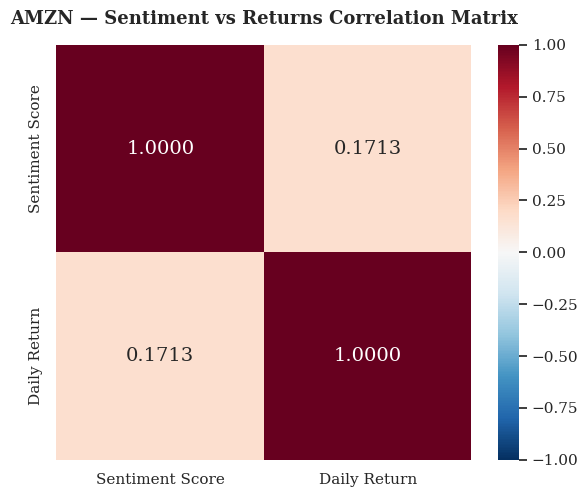

✅ Correlation heatmap rendered!


In [26]:
# Correlation heatmap
corr_matrix = merged_df[['compound', 'daily_return']].corr(
    method='pearson')
corr_matrix.index   = ['Sentiment Score', 'Daily Return']
corr_matrix.columns = ['Sentiment Score', 'Daily Return']

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, fmt='.4f',
            annot_kws={"size": 14})
plt.title('AMZN — Sentiment vs Returns Correlation Matrix',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print("✅ Correlation heatmap rendered!")

### 9.2 Scatter Plot — Sentiment vs Returns

The scatter plot below shows the relationship between daily sentiment
scores and daily stock returns, annotated with the Pearson correlation
coefficient and a regression line.

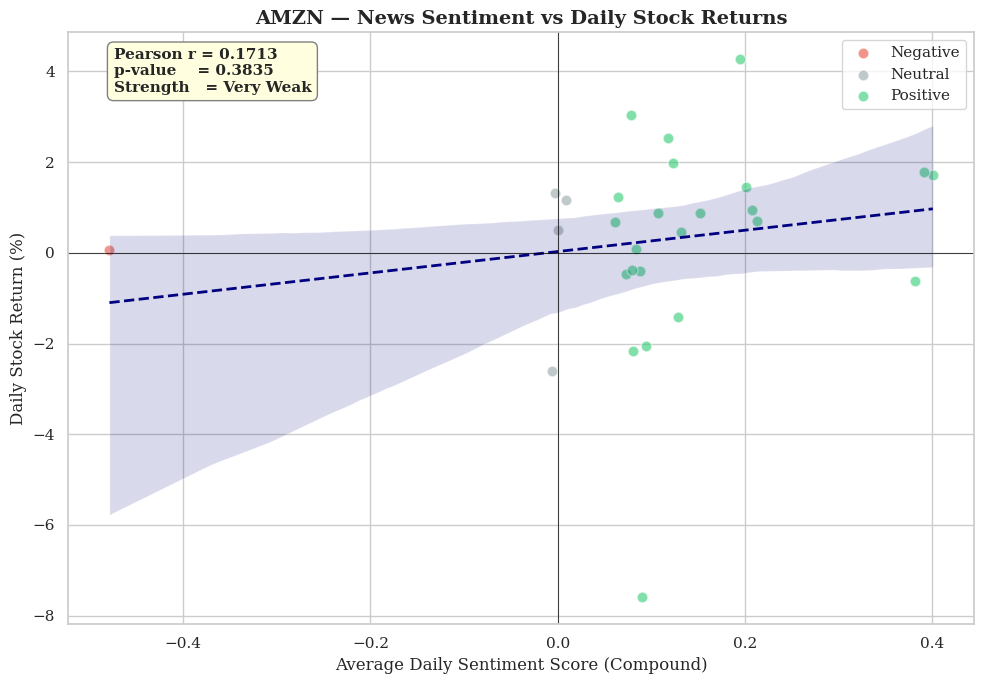

✅ Scatter plot rendered!


In [27]:
fig, ax = plt.subplots(figsize=(10, 7))

colors_map = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}

for label, group in merged_df.groupby('sentiment_label'):
    ax.scatter(group['compound'], group['daily_return'],
               c=colors_map[label], label=label,
               alpha=0.6, s=60, edgecolors='white')

# Regression line
sns.regplot(x='compound', y='daily_return', data=merged_df,
            scatter=False, ax=ax, color='navy',
            line_kws={'linewidth': 2, 'linestyle': '--'})

# Annotate
ax.annotate(
    f'Pearson r = {corr:.4f}\np-value    = {pval:.4f}\n'
    f'Strength   = {strength}',
    xy=(0.05, 0.90), xycoords='axes fraction',
    fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='lightyellow', edgecolor='gray'))

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('AMZN — News Sentiment vs Daily Stock Returns',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Daily Sentiment Score (Compound)',
              fontsize=12)
ax.set_ylabel('Daily Stock Return (%)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Scatter plot rendered!")

### 9.3 Average Daily Return by Sentiment Category

The bar chart below shows the average daily stock return for each
sentiment category, revealing whether positive news days are
associated with higher returns.

=== Average Daily Return by Sentiment Category ===
sentiment_label  avg_return  count      std
       Negative    0.055440      1      NaN
        Neutral    0.096191      4 1.835375
       Positive    0.328111     23 2.318744


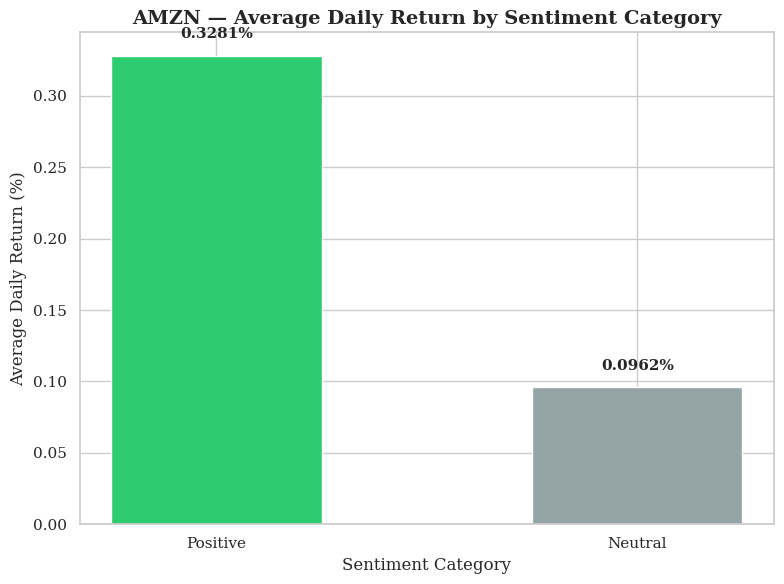

✅ Bar chart rendered!


In [28]:
# Average return per sentiment category
category_returns = merged_df.groupby(
    'sentiment_label')['daily_return'].agg(
    ['mean', 'count', 'std']).reset_index()
category_returns.columns = ['sentiment_label', 'avg_return',
                             'count', 'std']

print("=== Average Daily Return by Sentiment Category ===")
print(category_returns.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))

colors_bar = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}

# Ensure consistent order
order = ['Positive', 'Neutral', 'Negative']
cat_ordered = category_returns.set_index(
    'sentiment_label').reindex(order).reset_index()
cat_ordered = cat_ordered.dropna()

bars = ax.bar(
    cat_ordered['sentiment_label'],
    cat_ordered['avg_return'],
    color=[colors_bar[s] for s in cat_ordered['sentiment_label']],
    edgecolor='white', width=0.5)

for bar, val in zip(bars, cat_ordered['avg_return']):
    offset = 0.01 if val >= 0 else -0.05
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f'{val:.4f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('AMZN — Average Daily Return by Sentiment Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Category', fontsize=12)
ax.set_ylabel('Average Daily Return (%)', fontsize=12)
plt.tight_layout()
plt.show()
print("✅ Bar chart rendered!")

### 9.4 Sentiment Score & Stock Return Over Time

The time series chart shows how daily sentiment scores and daily
stock returns move together over the analysis period.

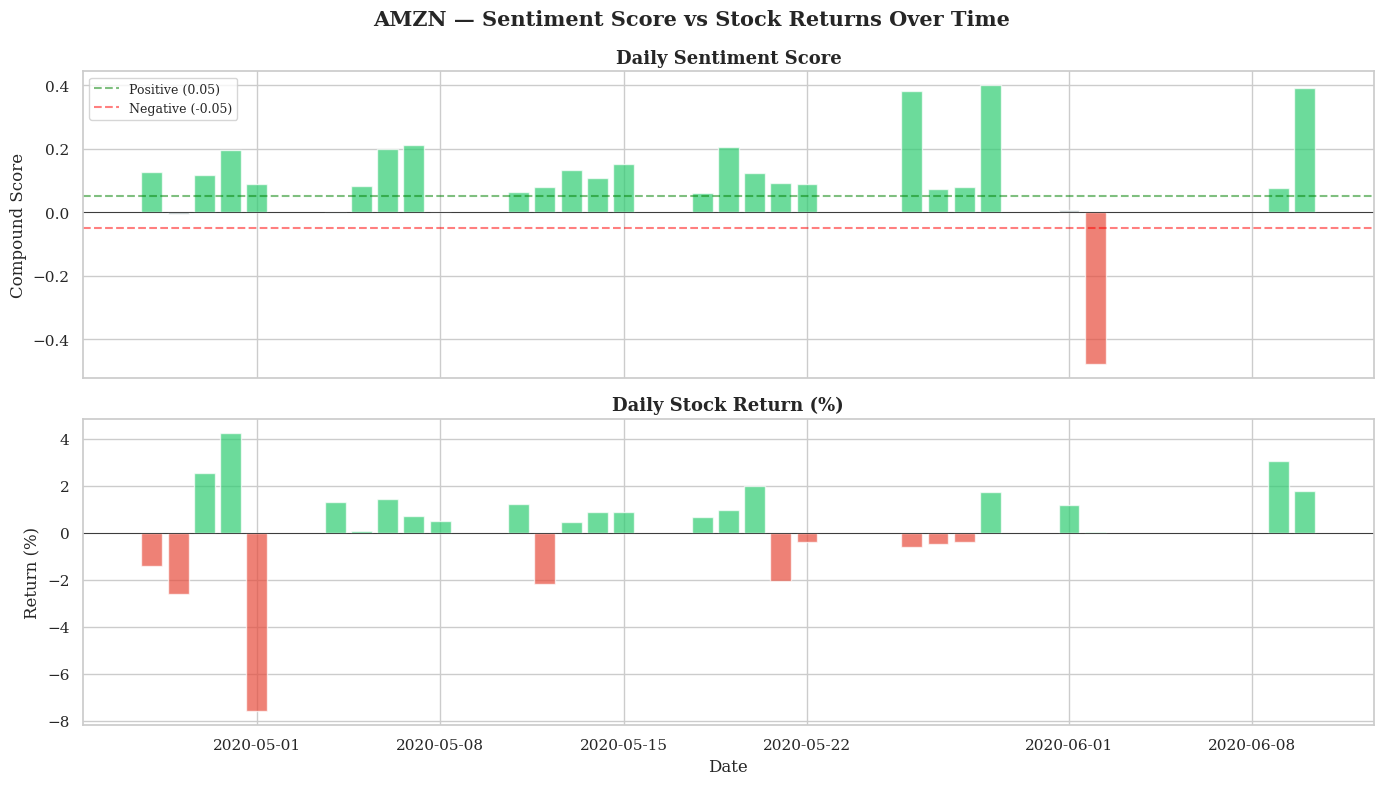

✅ Time series plot rendered!


In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Sentiment over time
axes[0].bar(merged_df['trading_date'], merged_df['compound'],
            color=['#2ecc71' if v >= 0.05
                   else '#e74c3c' if v <= -0.05
                   else '#95a5a6'
                   for v in merged_df['compound']],
            alpha=0.7)
axes[0].axhline(0.05,  color='green', linestyle='--',
                alpha=0.5, label='Positive (0.05)')
axes[0].axhline(-0.05, color='red',   linestyle='--',
                alpha=0.5, label='Negative (-0.05)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Daily Sentiment Score',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Compound Score')
axes[0].legend(fontsize=9)

# Returns over time
axes[1].bar(merged_df['trading_date'], merged_df['daily_return'],
            color=['#2ecc71' if v >= 0 else '#e74c3c'
                   for v in merged_df['daily_return']],
            alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Daily Stock Return (%)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Return (%)')
axes[1].set_xlabel('Date')

plt.suptitle('AMZN — Sentiment Score vs Stock Returns Over Time',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Time series plot rendered!")

## 10. Key Findings & Summary

In [30]:
print("=" * 55)
print("   AMZN SENTIMENT CORRELATION — KEY FINDINGS")
print("=" * 55)

print(f"""
📰 ANALYSIS OVERVIEW
- Total articles analyzed     : {len(amzn_news_scored)}
- Trading days matched        : {len(merged_df)}
- Date range                  : {merged_df['trading_date'].min().date()} to {merged_df['trading_date'].max().date()}

😊 SENTIMENT SUMMARY
- Average compound score      : {amzn_news_scored['compound'].mean():.4f}
- Positive articles           : {(amzn_news_scored['sentiment_label'] == 'Positive').sum()}
- Neutral articles            : {(amzn_news_scored['sentiment_label'] == 'Neutral').sum()}
- Negative articles           : {(amzn_news_scored['sentiment_label'] == 'Negative').sum()}

📈 CORRELATION RESULTS
- Pearson  r = {corr_results['pearson']['r']:+.4f}  p = {corr_results['pearson']['p']:.4f}  {'✅ Significant' if corr_results['pearson']['p'] < 0.05 else '❌ Not Significant'}
- Spearman r = {corr_results['spearman']['r']:+.4f}  p = {corr_results['spearman']['p']:.4f}  {'✅ Significant' if corr_results['spearman']['p'] < 0.05 else '❌ Not Significant'}
- Kendall  r = {corr_results['kendall']['r']:+.4f}  p = {corr_results['kendall']['p']:.4f}  {'✅ Significant' if corr_results['kendall']['p'] < 0.05 else '❌ Not Significant'}

- Pearson Strength            : {strength}
- Pearson Direction           : {direction}

📊 AVERAGE RETURNS BY SENTIMENT
""")
for _, row in cat_ordered.iterrows():
    print(f"  {row['sentiment_label']:10} : {row['avg_return']:.4f}% "
          f"(n={int(row['count'])})")

print("\n" + "=" * 55)

   AMZN SENTIMENT CORRELATION — KEY FINDINGS

📰 ANALYSIS OVERVIEW
- Total articles analyzed     : 278
- Trading days matched        : 28
- Date range                  : 2020-04-27 to 2020-06-10

😊 SENTIMENT SUMMARY
- Average compound score      : 0.1100
- Positive articles           : 137
- Neutral articles            : 94
- Negative articles           : 47

📈 CORRELATION RESULTS
- Pearson  r = +0.1713  p = 0.3835  ❌ Not Significant
- Spearman r = +0.2764  p = 0.1545  ❌ Not Significant
- Kendall  r = +0.1746  p = 0.2010  ❌ Not Significant

- Pearson Strength            : Very Weak
- Pearson Direction           : Positive

📊 AVERAGE RETURNS BY SENTIMENT

  Positive   : 0.3281% (n=23)
  Neutral    : 0.0962% (n=4)



## 11. Interpretation & Conclusion

**Correlation Interpretation:**
All three correlation methods show a **very weak positive relationship** between AMZN news sentiment and same-day stock returns, with a Pearson coefficient of +0.1713 (p=0.3835). The correlation is **not statistically significant**, and with only **28 matched trading days** this is the smallest sample in our analysis, severely limiting statistical power.

**Sentiment Category Analysis:**
The bar chart shows positive sentiment days averaged **+0.33% returns** and neutral days averaged **+0.10%**. Notably, there were no negative sentiment category days in the matched dataset — this is consistent with Amazon's overwhelmingly bullish news coverage during the pandemic period, where analysts frequently raised price targets due to e-commerce and AWS demand surges. The absence of negative sentiment days makes a full three-category comparison impossible for AMZN.

**Limitations:**
- With only **28 matched trading days** (April–June 2020), this is an extremely small sample that makes any statistical conclusion unreliable
- Amazon's pandemic narrative was almost entirely positive, creating a **sentiment distribution imbalance** that prevents meaningful negative sentiment analysis
- The short date range of approximately **6 weeks** is insufficient to capture the full range of sentiment-return dynamics
- **Same-day alignment** may miss delayed market reactions to news published after market close